# Large-Scale Geographic Consumer Clustering & High-Dimensional Visualizations
This notebook loads the provided Chennai real-estate dataset, performs K-Means clustering, visualizes the clusters using PCA and Plotly, and creates an interactive Folium map.

In [1]:
# Install once if needed
# !pip install pandas numpy scikit-learn matplotlib plotly folium umap-learn

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display

# Load dataset
df = pd.read_csv("/content/Chennai_Real_Estate_Dataset.csv")
print(df.head())
print(df.shape)

   PropertyID    Locality   Latitude  Longitude     Price  Area  Bedrooms  \
0           1   Perungudi  12.965534  80.249544  15046004  1676         1   
1           2  Anna Nagar  13.085107  80.200631   9851480   680         5   
2           3    Tambaram  12.928863  80.096805  16460980  1452         5   
3           4   Velachery  12.986050  80.223275  13468808   968         2   
4           5      Guindy  13.006264  80.223073  44556824  2746         1   

   Bathrooms  PropertyAge Parking PropertyType  
0          1            7     Yes    Apartment  
1          4            0     Yes    Apartment  
2          4           14      No    Apartment  
3          2            2      No    Apartment  
4          2            3      No    Apartment  
(1000, 11)


In [5]:
features = ["Price","Area","Bedrooms","Bathrooms","PropertyAge"]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print(df["Cluster"].value_counts())

Cluster
3    283
1    267
2    234
0    216
Name: count, dtype: int64


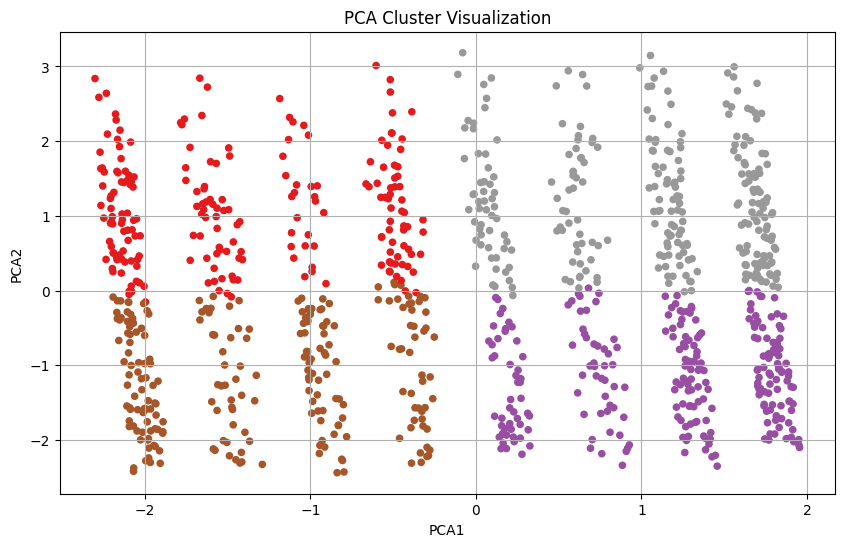

In [6]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

df["PCA1"] = pca_data[:,0]
df["PCA2"] = pca_data[:,1]

plt.figure(figsize=(10,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap="Set1", s=20)
plt.title("PCA Cluster Visualization")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.show()

In [7]:
fig = px.scatter(
    df,
    x="PCA1",
    y="PCA2",
    color=df["Cluster"].astype(str),
    hover_data=["Locality","Price","Area","Bedrooms"],
    title="Interactive Consumer Clusters"
)
fig.show()

In [8]:
center=[df["Latitude"].mean(),df["Longitude"].mean()]

m = folium.Map(location=center, zoom_start=11)

marker_cluster = MarkerCluster().add_to(m)

colors=["red","blue","green","purple"]

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"],row["Longitude"]],
        radius=5,
        color=colors[int(row["Cluster"])],
        fill=True,
        fill_color=colors[int(row["Cluster"])],
        fill_opacity=0.8,
        popup=f"""
        <b>Locality:</b> {row['Locality']}<br>
        <b>Price:</b> ₹{row['Price']:,}<br>
        <b>Area:</b> {row['Area']} sqft<br>
        <b>Cluster:</b> {row['Cluster']}
        """
    ).add_to(marker_cluster)

HeatMap(df[["Latitude","Longitude"]].values.tolist(), radius=12).add_to(m)

m.save("housing_clusters_map.html")

display(m)


In [9]:
summary = df.groupby("Cluster")[features].mean()
display(summary)

df.to_csv("clustered_properties.csv", index=False)

print("Files generated:")
print("1. clustered_properties.csv")
print("2. housing_clusters_map.html")

,Price,Area,Bedrooms,Bathrooms,PropertyAge
Cluster,,,,,
0,3.456722e+07,2542.754630,1.666667,1.666667,12.912037
1,1.594946e+07,1212.846442,4.071161,3.734082,12.127341
2,1.650445e+07,1330.700855,1.692308,1.662393,13.260684
3,3.470665e+07,2513.848057,4.063604,3.717314,12.530035


Files generated:
1. clustered_properties.csv
2. housing_clusters_map.html
